# Lab 5b — Difference-in-Differences: Did the Regional Reminder Rollout Work?
# المعمل 5ب — الفروق في الفروق: هل نجح تفعيل التذكيرات على مستوى المناطق؟

**Module 5 — Quasi-Experiments: Matching, Difference-in-Differences and Instrumental Variables**
**الوحدة 5 — التجارب شبه المضبوطة: المطابقة والفروق في الفروق والمتغيرات الأداتية**

*SDA-DSC-213 · SDAIA Academy · Day 3, Hour 4 · 50 minutes*

---

## The situation

Injaz switched on an SMS/push **reminder programme** region by region over six months —
in four waves, for operational reasons, not experimental ones. Four regions never got it.

The dashboard says completion in the activated regions rose **+4.8 pp** from before to after.
A SAR 90M annual extension hinges on that number.

But national digital adoption was climbing anyway. Some of that +4.8 pp is the programme and
some of it is the tide. **Your job is to separate them.**

The staggered rollout is a gift: at any moment there are regions that have the programme and
regions that do not *yet*. The not-yet-treated regions tell you what the tide alone was doing.

| | |
|---|---|
| **Objective** | Estimate the reminder effect with TWFE DiD + event study, test parallel trends, run a placebo-timing test, and see what a parallel-trends **failure** looks like |
| **Data** | `injaz_regions_panel.csv` (13 regions × 24 months) and `injaz_regions_panel_pretrend.csv` |
| **Estimand** | **ATT** on completion rate in activated regions |
| **Ground truth** | The full effect was **planted** at **+3.0 pp with a two-month ramp-in**. Do not look yet. |

### Bilingual key terms (first use)

| English | العربية |
|---|---|
| Difference-in-differences | الفروق في الفروق |
| Parallel trends | الاتجاهات المتوازية |
| Event study | دراسة الأحداث |
| Two-way fixed effects (TWFE) | التأثيرات الثابتة ثنائية الاتجاه |
| Placebo test | اختبار وهمي |


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make `causal_utils` importable from anywhere under course_assets/
ROOT = Path.cwd()
while not (ROOT / "causal_utils").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causal_utils import use_sdaia_style
use_sdaia_style()

RANDOM_SEED = 213          # fixed for every lab: reproducibility is graded
rng = np.random.default_rng(RANDOM_SEED)
print("Environment ready ·", ROOT)

Environment ready · /home/claude/course_assets


In [2]:
# --- lab scaffolding: self-checks that never crash the notebook ----------
def check(name, fn):
    """Run a self-check. Prints PASS/FAIL/TODO instead of raising, so the
    notebook always runs top-to-bottom even with unfinished exercises."""
    try:
        fn()
    except AssertionError as e:
        print(f"[ TODO ]  {name}: {e}")
        return False
    except Exception as e:
        print(f"[ ERROR ] {name}: {type(e).__name__}: {e}")
        return False
    print(f"[  OK  ]  {name}")
    return True


def needs(*objs, msg="complete the TODO cell above first"):
    """Guard downstream cells so an unfinished TODO skips rather than crashes."""
    if any(o is None for o in objs):
        print(f"[ SKIPPED ] {msg}")
        return False
    return True

print("Scaffolding loaded: use check(...) to self-test and needs(...) to guard.")

Scaffolding loaded: use check(...) to self-test and needs(...) to guard.


## Step 1 — Inspect the panel and the rollout waves *(10 min)*

A DiD analysis is only as good as the panel it sits on. Before estimating anything, know:
who is treated, **when**, and who is never treated.

In [3]:
from causal_utils import NAVY, BLUE, ORANGE, TEAL, SLATE, MUTED

panel = pd.read_csv(DATA / "injaz_regions_panel.csv")
print(f"{len(panel)} rows · {panel['region'].nunique()} regions × "
      f"{panel['period'].nunique()} months")

waves = (panel.groupby("activation_month")["region"].nunique()
         .rename("n_regions").reset_index())
never = panel.loc[panel["activation_month"].isna(), "region"].nunique()
print("\nActivation waves (period at which the programme switched on):")
print(waves.to_string(index=False))
print(f"Never-treated regions: {never}")
panel.head(3)

312 rows · 13 regions × 24 months

Activation waves (period at which the programme switched on):
 activation_month  n_regions
             10.0          2
             13.0          2
             16.0          2
             19.0          3
Never-treated regions: 4


,region,month,period,activation_month,treated_ever,post,treated_post,months_since_activation,eligible_users,reminders_sent,completion_rate,completions
0,Riyadh,2025-01,1,10.0,1,0,0,-9.0,20164,0,0.48921,9864
1,Riyadh,2025-02,2,10.0,1,0,0,-8.0,20304,0,0.49217,9993
2,Riyadh,2025-03,3,10.0,1,0,0,-7.0,20384,0,0.50114,10215


In [4]:
tr = panel[panel["treated_ever"] == 1]
naive_ba = float(tr.loc[tr["post"] == 1, "completion_rate"].mean()
                 - tr.loc[tr["post"] == 0, "completion_rate"].mean())

print(f"Naive before/after (treated regions only): {100*naive_ba:+.2f} pp   <- the dashboard")

def _c():
    assert naive_ba is not None, "naive_ba is still None"
    assert 0.04 < naive_ba < 0.08, f"expected roughly +6 pp, got {100*naive_ba:+.2f} pp"
check("naive before/after reproduced", _c)

Naive before/after (treated regions only): +4.79 pp   <- the dashboard
[  OK  ]  naive before/after reproduced


True

### Step 1b — The two-lines picture

The DiD intuition in one chart: treated regions and never-treated regions, plotted over
calendar time. If the two lines move in parallel *before* the first activation, the
never-treated line is a credible stand-in for what the treated regions would have done.

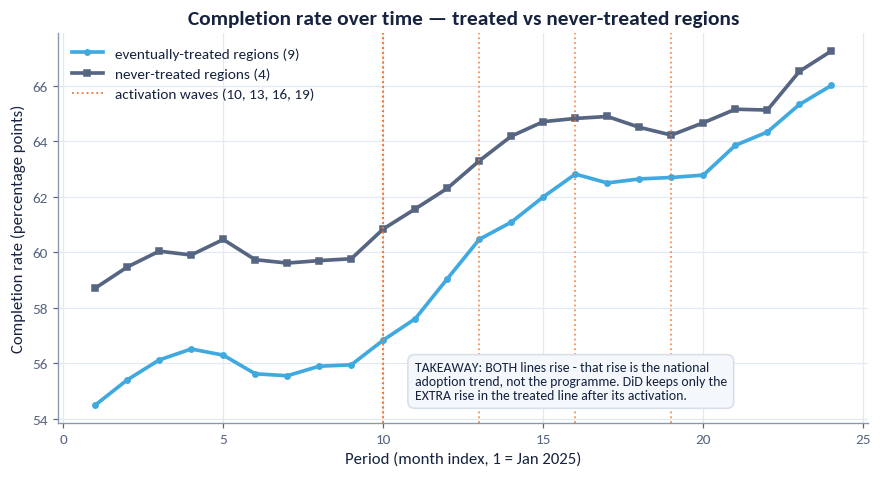

In [5]:
g = (panel.groupby(["period", "treated_ever"])["completion_rate"].mean()
     .unstack() * 100)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(g.index, g[1], color=BLUE, lw=2.4, marker="o", ms=3.5,
        label="eventually-treated regions (9)")
ax.plot(g.index, g[0], color=SLATE, lw=2.4, marker="s", ms=3.5,
        label="never-treated regions (4)")
for w in sorted(panel["activation_month"].dropna().unique()):
    ax.axvline(w, color=ORANGE, ls=":", lw=1.2, alpha=0.8)
ax.axvline(sorted(panel["activation_month"].dropna().unique())[0], color=ORANGE,
           ls=":", lw=1.2, label="activation waves (10, 13, 16, 19)")
ax.set_title("Completion rate over time — treated vs never-treated regions")
ax.set_xlabel("Period (month index, 1 = Jan 2025)")
ax.set_ylabel("Completion rate (percentage points)")
ax.legend(loc="upper left")
ax.annotate(
    "TAKEAWAY: BOTH lines rise - that rise is the national\n"
    "adoption trend, not the programme. DiD keeps only the\n"
    "EXTRA rise in the treated line after its activation.",
    xy=(0.44, 0.06), xycoords="axes fraction", fontsize=9, color=NAVY,
    bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec="#D6DEEA"))
plt.show()

> ### Instructor note — Step 1
>
> **Teaching point.** Put the naive **+4.79 pp** and the two-lines chart on screen together
> and ask: "how much of that +4.8 belongs to the grey line?" The national tide is worth about
> 2.2 pp of it over the same window. Participants can *see* the answer before any regression, which
> is exactly the point of leading with the picture.
>
> **Common wrong answer.** "The treated line is higher, so the programme works." Level
> differences are absorbed by region fixed effects; DiD looks at *changes*, not levels. Some
> participants will also try to read the effect off the gap at the far right — that is the
> before/after error with extra steps.
>
> **Expected output.** Naive before/after ≈ **+4.79 pp**.

## Step 2 — The identifying assumption, in words, first

> **Parallel trends** (*الاتجاهات المتوازية*): absent the reminder programme, completion in
> the activated regions would have moved *in parallel* with completion in the regions that
> had not yet been activated.

This is **not directly testable** — the counterfactual is missing by construction. What you
*can* do, and must, is show that the **pre-period** was parallel, and then say honestly that
you are extrapolating that parallelism forward.

In [6]:
IDENTIFYING_ASSUMPTION = (
    "Parallel trends: absent the reminder programme, completion rates in activated "
    "regions would have followed the same time path as in not-yet-activated and "
    "never-treated regions."
)
CREDIBLE_THREAT = (
    "A region-specific campaign, staffing change or service launch that coincided with "
    "reminder activation would violate it - the rollout order was operational, and "
    "operational priorities correlate with other investments."
)
print("IDENTIFYING ASSUMPTION\n  " + IDENTIFYING_ASSUMPTION)
print("\nCREDIBLE THREAT\n  " + CREDIBLE_THREAT)
print("\nHOW WE SUPPORT IT\n  1. event study: pre-period coefficients flat and ~zero"
      "\n  2. placebo timing: pretend activation happened 6 months earlier -> null")

IDENTIFYING ASSUMPTION
  Parallel trends: absent the reminder programme, completion rates in activated regions would have followed the same time path as in not-yet-activated and never-treated regions.

CREDIBLE THREAT
  A region-specific campaign, staffing change or service launch that coincided with reminder activation would violate it - the rollout order was operational, and operational priorities correlate with other investments.

HOW WE SUPPORT IT
  1. event study: pre-period coefficients flat and ~zero
  2. placebo timing: pretend activation happened 6 months earlier -> null


## Step 3 — TWFE difference-in-differences *(12 min)*

The regression form:

```
completion_rate ~ treated_post + C(region) + C(period)
```

Region fixed effects absorb every permanent difference between regions. Period fixed effects
absorb the national trend. What is left on `treated_post` is the DiD estimate.

**Standard errors must be clustered on region.** Months within a region are correlated;
pretending otherwise gives an interval that is far too narrow. With only 13 clusters, treat
the interval as approximate and say so.

In [7]:
from causal_utils import did_twfe

did = did_twfe(panel, outcome="completion_rate", unit="region",
               time="period", treated_post="treated_post")
print(did)
print(f"\nNaive before/after was {100*naive_ba:+.2f} pp;")
print(f"differencing out the national trend leaves {100*did.att:+.2f} pp.")
print(f"The trend was worth {100*(naive_ba - did.att):+.2f} pp of the headline.")

def _c():
    assert did is not None, "did is still None"
    assert 0.015 < did.att < 0.035, f"DiD of {100*did.att:+.2f} pp is outside the plausible band"
    assert did.n_units == 13, "all 13 regions should contribute"
check("TWFE DiD estimated with clustered SEs", _c)

Difference-in-differences (TWFE)
  ATT : +2.61 pp [+2.48, +2.74]
  se  : 0.00069   p = 0
  312 observations across 13 units

Naive before/after was +4.79 pp;
differencing out the national trend leaves +2.61 pp.
The trend was worth +2.18 pp of the headline.
[  OK  ]  TWFE DiD estimated with clustered SEs


True

> ### Instructor note — Step 3
>
> **Teaching point.** The headline nearly halves: **+4.79 pp → +2.61 pp**. That 2.18 pp is the
> national tide, and it would have been claimed as programme impact by a before/after report.
> In riyals, on a SAR 90M decision, that is the whole lab justified.
>
> **Common wrong answer.** Running the same regression with default (non-clustered) SEs. The
> interval comes out roughly half as wide and looks *better*, which is exactly why it is
> dangerous. If a pair reports a suspiciously tight CI, check `cov_type`.
>
> **Second common error.** Adding `reminders_sent` as a "control." It is a *consequence* of
> activation — a post-treatment variable that partly absorbs the treatment. This is the
> debugging exercise at the end of the lab.
>
> **Expected output.** ATT ≈ **+2.61 pp** [+2.48, +2.74], clustered on 13 regions.

## Step 4 — The event study: the parallel-trends exhibit *(12 min)*

This is the single most important chart in observational programme evaluation, and the one
most likely to appear in your capstone.

Instead of one average effect, estimate **one coefficient per month relative to activation**,
with month −1 omitted as the baseline. Then read it in this order:

1. **Are the pre-period coefficients flat and centred on zero?** If not, parallel trends is
   already contradicted and the DiD number is not a causal estimate, whatever its p-value.
2. **Does the effect appear at activation, not before it?**
3. **Does it ramp, persist or decay?** That shapes the scaling decision as much as the
   average does.

In [8]:
from causal_utils import event_study

es = event_study(panel, outcome="completion_rate", unit="region", time="period",
                 rel_time="months_since_activation", window=(-6, 8))
print(es.round(4).to_string(index=False))

def _c():
    assert es is not None, "es is still None"
    pre = es[(es.period == "pre") & (~es.is_baseline)]
    assert pre["coef"].abs().max() < 0.01, "pre-period coefficients are not flat"
    assert es.loc[es.rel_time == 0, "coef"].iat[0] > 0.005, "no jump at activation"
check("event study: flat pre-period, jump at activation", _c)

 rel_time    coef     se  ci_low  ci_high  is_baseline period
       -6  0.0030 0.0031 -0.0031   0.0090        False    pre
       -5  0.0013 0.0024 -0.0034   0.0059        False    pre
       -4 -0.0014 0.0032 -0.0078   0.0049        False    pre
       -3  0.0042 0.0027 -0.0011   0.0095        False    pre
       -2  0.0026 0.0026 -0.0025   0.0078        False    pre
       -1  0.0000 0.0000  0.0000   0.0000         True    pre
        0  0.0206 0.0039  0.0131   0.0282        False   post
        1  0.0164 0.0025  0.0115   0.0213        False   post
        2  0.0338 0.0030  0.0278   0.0398        False   post
        3  0.0324 0.0026  0.0273   0.0375        False   post
        4  0.0328 0.0030  0.0269   0.0387        False   post
        5  0.0341 0.0024  0.0294   0.0388        False   post
        6  0.0335 0.0026  0.0284   0.0386        False   post
        7  0.0322 0.0029  0.0265   0.0379        False   post
        8  0.0294 0.0021  0.0253   0.0336        False   post
[  OK  ]

True

### Step 4b — Plot it

A reusable plotting function — you will call it again in a moment on a *broken* dataset, and
again in the capstone.

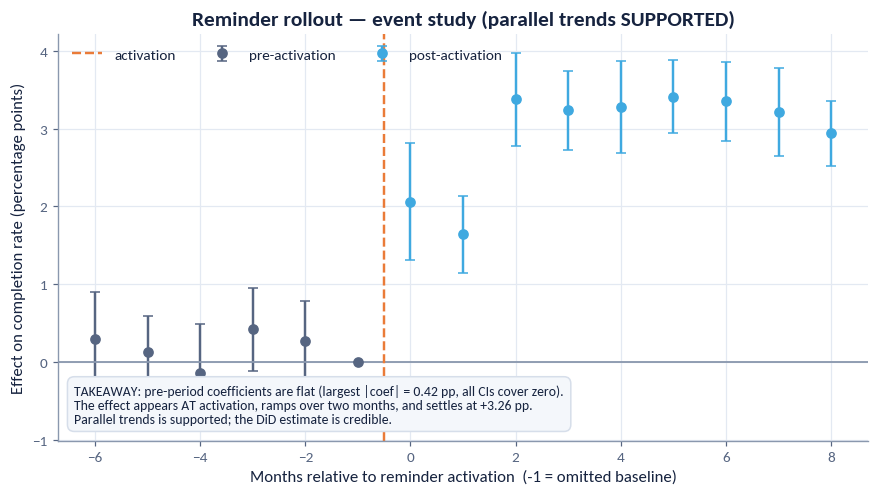

In [9]:
def plot_event_study(es_df, ax=None, title="Event study", subtitle=""):
    """Coefficient by month relative to activation, with 95% CIs.

    Pre-period points slate, post-period blue; the activation boundary is the
    dashed vertical line between rel_time -1 and 0."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9.5, 4.8))
    pre = es_df[es_df["period"] == "pre"]
    post = es_df[es_df["period"] == "post"]
    for sub, col, lab in ((pre, SLATE, "pre-activation"), (post, BLUE, "post-activation")):
        ax.errorbar(sub["rel_time"], sub["coef"] * 100,
                    yerr=[(sub["coef"] - sub["ci_low"]) * 100,
                          (sub["ci_high"] - sub["coef"]) * 100],
                    fmt="o", ms=6, lw=1.6, capsize=3, color=col, label=lab)
    ax.axhline(0, color=MUTED, lw=1.2)
    ax.axvline(-0.5, color=ORANGE, ls="--", lw=1.6, label="activation")
    ax.set_title(title)
    ax.set_xlabel("Months relative to reminder activation  (-1 = omitted baseline)")
    ax.set_ylabel("Effect on completion rate (percentage points)")
    ax.legend(loc="upper left", ncols=3)
    if subtitle:
        ax.annotate(subtitle, xy=(0.02, 0.04), xycoords="axes fraction",
                    fontsize=9, color=NAVY, va="bottom",
                    bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec="#D6DEEA"))
    return ax


pre_max = es[(es.period == "pre") & (~es.is_baseline)]["coef"].abs().max()
settled = es[es.rel_time >= 2]["coef"].mean()
plot_event_study(
    es,
    title="Reminder rollout — event study (parallel trends SUPPORTED)",
    subtitle=(f"TAKEAWAY: pre-period coefficients are flat (largest |coef| = "
              f"{100*pre_max:.2f} pp, all CIs cover zero).\n"
              f"The effect appears AT activation, ramps over two months, and settles at "
              f"{100*settled:+.2f} pp.\nParallel trends is supported; the DiD estimate is "
              f"credible."))
plt.show()

> ### Instructor note — Step 4
>
> **Teaching point.** Walk the class along the x-axis with a finger. Pre-period: −0.14 to
> +0.42 pp, every CI covering zero. Month 0: +2.06 pp. Month 1: +1.64 pp. Month 2 onwards:
> hovering around +3.3 pp.
>
> **That last observation is the whole "attenuation" lesson.** The TWFE average is +2.61 pp,
> but the *settled* effect is ≈ +3.26 pp. TWFE averages the two low ramp-in months in with the
> mature months and therefore under-states the steady-state effect. This is **not a bug and
> not bias** — it is the correct average of a time-varying effect, and the event study is what
> lets you see the difference. In the memo you report *both*: "+2.6 pp on average over the
> first year; +3.3 pp once the programme matures."
>
> **Common wrong answer.** "The DiD is wrong, it should be 3.3." No — DiD answered the
> question "what was the average effect over the observed post-period?" faithfully. Different
> question, different number.
>
> **If stuck.** They forget `window=(-6, 8)` and get a coefficient for every relative month
> including cells with two observations, producing enormous CIs at the edges. Clipping the
> window pools the tails, which is standard practice.

## Step 5 — What a parallel-trends **failure** looks like *(10 min)*

Everything above assumed the pre-period was flat, and it was. Now run the identical analysis
on `injaz_regions_panel_pretrend.csv` — the same rollout, except the treated regions were
already pulling away from the controls *before* activation.

**You must be able to recognise this chart instantly.** In the wild nobody labels the file
"pretrend".

In [10]:
panel_bad = pd.read_csv(DATA / "injaz_regions_panel_pretrend.csv")
did_bad = did_twfe(panel_bad, outcome="completion_rate", unit="region",
                   time="period", treated_post="treated_post")
es_bad = event_study(panel_bad, outcome="completion_rate", unit="region",
                     time="period", rel_time="months_since_activation",
                     window=(-6, 8))
print(did_bad)
print(f"\nClean panel DiD    : {100*did.att:+.2f} pp")
print(f"Pretrend panel DiD : {100*did_bad.att:+.2f} pp   <- inflated by "
      f"{100*(did_bad.att - did.att):+.2f} pp of pre-existing divergence")

def _c():
    assert es_bad is not None, "es_bad is still None"
    pre = es_bad[(es_bad.period == "pre") & (~es_bad.is_baseline)]
    assert pre["coef"].abs().max() > 0.01, \
        "you should be seeing a NON-flat pre-period here - check you loaded the pretrend file"
check("parallel-trends violation detected in the pretrend panel", _c)

Difference-in-differences (TWFE)
  ATT : +4.24 pp [+3.27, +5.20]
  se  : 0.00493   p = 7.796e-18
  312 observations across 13 units

Clean panel DiD    : +2.61 pp
Pretrend panel DiD : +4.24 pp   <- inflated by +1.63 pp of pre-existing divergence
[  OK  ]  parallel-trends violation detected in the pretrend panel


True

### Step 5b — Side by side: the credibility exhibit

Same estimator. Same rollout. One of these DiD estimates means something.

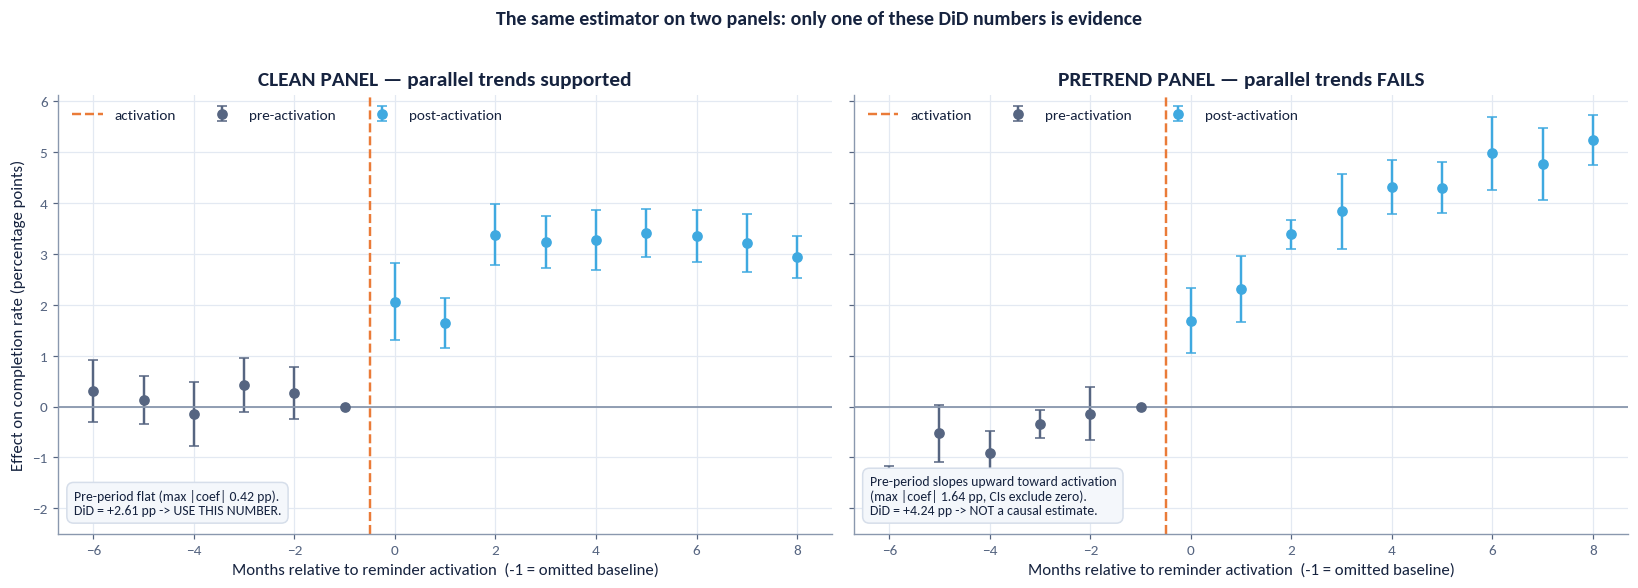

clean    : pre-period max |coef| = 0.42 pp   DiD = +2.61 pp
pretrend : pre-period max |coef| = 1.64 pp   DiD = +4.24 pp

The pretrend panel's DiD is inflated by +1.63 pp - and nothing
in the DiD output itself would have told you. Only the event study does.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)

pre_ok = es[(es.period == "pre") & (~es.is_baseline)]["coef"].abs().max()
pre_bad = es_bad[(es_bad.period == "pre") & (~es_bad.is_baseline)]["coef"].abs().max()

plot_event_study(es, ax=axes[0],
                 title="CLEAN PANEL — parallel trends supported",
                 subtitle=(f"Pre-period flat (max |coef| {100*pre_ok:.2f} pp).\n"
                           f"DiD = {100*did.att:+.2f} pp -> USE THIS NUMBER."))
plot_event_study(es_bad, ax=axes[1],
                 title="PRETREND PANEL — parallel trends FAILS",
                 subtitle=(f"Pre-period slopes upward toward activation\n"
                           f"(max |coef| {100*pre_bad:.2f} pp, CIs exclude zero).\n"
                           f"DiD = {100*did_bad.att:+.2f} pp -> NOT a causal estimate."))
axes[1].set_ylabel("")
fig.suptitle("The same estimator on two panels: only one of these DiD numbers is evidence",
             fontsize=13, color=NAVY, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"clean    : pre-period max |coef| = {100*pre_ok:.2f} pp   DiD = {100*did.att:+.2f} pp")
print(f"pretrend : pre-period max |coef| = {100*pre_bad:.2f} pp   DiD = {100*did_bad.att:+.2f} pp")
print(f"\nThe pretrend panel's DiD is inflated by {100*(did_bad.att - did.att):+.2f} pp - and "
      "nothing\nin the DiD output itself would have told you. Only the event study does.")

> ### Instructor note — Step 5
>
> **Teaching point.** This is the lab's payoff slide. The pretrend panel's DiD, **+4.24 pp
> [+3.27, +5.20]**, is *more significant* than the clean one and would sail through any
> review that stopped at the regression table. The event study is the only thing that catches
> it. Say the sentence: "a tight confidence interval on a violated assumption is a confident
> wrong answer."
>
> **Common wrong answer.** "The pre-trend is small, so it's fine." Ask them to extrapolate the
> pre-period slope forward six months and subtract it from the post coefficients — most of the
> "effect" survives, but not all, and the honest report is a *range* plus a statement that DiD
> is not identified here.
>
> **The right professional move when you see this chart:** report the failure, do not report
> the number. Troubleshooting table, row 4: "DiD not identified here; report the failure
> honestly."
>
> **Expected output.** Clean pre-period max |coef| 0.42 pp; pretrend max |coef| 1.64 pp with
> CIs excluding zero; DiD +2.61 pp vs +4.24 pp.

## Step 6 — Placebo-timing test *(8 min)*

The event study is a *visual* test. The placebo-timing test is its *numeric* twin: pretend
activation happened **six months earlier than it did**, throw away all genuinely-treated
observations, and re-estimate. Since nothing actually happened at the fake date, the estimate
must be null.

Run it on both panels. It should pass on the clean one and fail on the broken one.

In [12]:
def placebo_timing(panel_df, shift=6):
    """Pretend activation happened `shift` months early, on PRE-period data only.

    Dropping all genuinely-treated rows is the essential step: leave them in and
    the 'placebo' quietly picks up the real effect and the test is meaningless.
    """
    d = panel_df.copy()
    d["fake_activation"] = d["activation_month"] - shift
    d = d[(d["activation_month"].isna()) | (d["period"] < d["activation_month"])].copy()
    d["placebo_post"] = ((d["treated_ever"] == 1)
                         & (d["period"] >= d["fake_activation"])).astype(int)
    return d


pl_clean = did_twfe(placebo_timing(panel), "completion_rate", "region",
                    "period", "placebo_post")
pl_bad = did_twfe(placebo_timing(panel_bad), "completion_rate", "region",
                  "period", "placebo_post")

print("PLACEBO TIMING (activation shifted 6 months earlier, post-period rows dropped)")
print(f"  clean panel    : {100*pl_clean.att:+.2f} pp "
      f"[{100*pl_clean.ci_low:+.2f}, {100*pl_clean.ci_high:+.2f}]  p = {pl_clean.p_value:.3f}"
      f"   -> {'PASS (null, as required)' if pl_clean.p_value > 0.05 else 'FAIL'}")
print(f"  pretrend panel : {100*pl_bad.att:+.2f} pp "
      f"[{100*pl_bad.ci_low:+.2f}, {100*pl_bad.ci_high:+.2f}]  p = {pl_bad.p_value:.2g}"
      f"   -> {'PASS' if pl_bad.p_value > 0.05 else 'FAIL (a non-event has an effect)'}")

def _c():
    assert pl_clean is not None and pl_bad is not None, "placebo results still None"
    assert pl_clean.p_value > 0.05, "placebo on the CLEAN panel should be null"
    assert pl_bad.p_value < 0.05, "placebo on the PRETREND panel should fire"
check("placebo timing: null on clean, fires on pretrend", _c)

PLACEBO TIMING (activation shifted 6 months earlier, post-period rows dropped)
  clean panel    : -0.13 pp [-0.47, +0.20]  p = 0.440   -> PASS (null, as required)
  pretrend panel : +1.07 pp [+0.56, +1.58]  p = 3.7e-05   -> FAIL (a non-event has an effect)
[  OK  ]  placebo timing: null on clean, fires on pretrend


True

> ### Instructor note — Step 6
>
> **Teaching point.** Step 2 of `placebo_timing` is where everyone goes wrong: if you do not
> drop the genuinely-treated rows, the "placebo" window includes real treatment and the test
> reports a large effect on the clean panel too. When a pair's clean-panel placebo fires,
> that is almost always the bug. Make them find it rather than telling them.
>
> **Common wrong answer.** "The placebo test proves parallel trends." It does not prove
> anything — it is a *falsification* test. It can only fail informatively. Same logic as the
> refuters in Lab 5a.
>
> **Expected output.** Clean: **−0.13 pp, p = 0.44** (null → pass). Pretrend: **+1.07 pp,
> p ≈ 3.7e−5** (a non-event with an "effect" → the design is producing the number).

## Step 7 — The staggered-rollout caveat *(6 min)*

Modern DiD literature has a warning for exactly this design: with **staggered** adoption and
effects that change over time, TWFE implicitly uses **already-treated** units as controls,
and some of the implicit comparison weights can be **negative**. In bad cases the estimate is
biased, occasionally even wrong-signed.

The fixes are cohort-aware estimators — **Callaway–Sant'Anna**, **Sun–Abraham**. Neither is
installed here, and neither is needed to make the point. Instead, run the **clean 2×2**: the
first wave (activated at period 10) against the **never-treated** regions only. No
already-treated unit is ever used as a control in that comparison.

If the clean comparison agrees with full TWFE, the negative-weights problem is not biting
here — and you can say that in the memo instead of hand-waving.

In [13]:
clean_2x2 = panel[(panel["activation_month"] == 10)
                  | (panel["activation_month"].isna())].copy()
did_clean = did_twfe(clean_2x2, "completion_rate", "region", "period", "treated_post")

print(did_clean)
print(f"\nFull staggered TWFE     : {100*did.att:+.2f} pp "
      f"[{100*did.ci_low:+.2f}, {100*did.ci_high:+.2f}]  (13 regions)")
print(f"Clean wave-1 vs never   : {100*did_clean.att:+.2f} pp "
      f"[{100*did_clean.ci_low:+.2f}, {100*did_clean.ci_high:+.2f}]  (6 regions)")
print(f"Gap                     : {100*(did.att - did_clean.att):+.2f} pp")
print("\nThe two agree to within a tenth of a point, so the negative-weights problem")
print("is not materially biting in this panel. That sentence belongs in the memo -")
print("naming the risk and showing it is small is worth more than ignoring it.")

def _c():
    assert did_clean is not None, "did_clean is still None"
    assert did_clean.n_units == 6, "wave-1 regions + never-treated regions should be 6 units"
    assert abs(did_clean.att - did.att) < 0.01, \
        "a >1 pp gap here would be evidence of staggered-TWFE bias"
check("clean not-yet-treated comparison agrees with full TWFE", _c)

Difference-in-differences (TWFE)
  ATT : +2.54 pp [+2.44, +2.65]
  se  : 0.00053   p = 0
  144 observations across 6 units

Full staggered TWFE     : +2.61 pp [+2.48, +2.74]  (13 regions)
Clean wave-1 vs never   : +2.54 pp [+2.44, +2.65]  (6 regions)
Gap                     : +0.07 pp

The two agree to within a tenth of a point, so the negative-weights problem
is not materially biting in this panel. That sentence belongs in the memo -
naming the risk and showing it is small is worth more than ignoring it.
[  OK  ]  clean not-yet-treated comparison agrees with full TWFE


True

### Optional — the DoWhy / cohort-estimator equivalents

Not installed here. The cell degrades gracefully and explains the mapping.

In [14]:
# --- OPTIONAL: packages you would reach for outside this training image ----
try:
    from dowhy import CausalModel                       # noqa: F401
    print("DoWhy available - a DiD estimand can be declared via a graph with "
          "unit and time fixed effects.")
except ImportError:
    print("DoWhy not installed - expected. The identify -> estimate -> refute\n"
          "workflow was still executed in full above:\n"
          "  identify -> parallel-trends assumption stated in Step 2\n"
          "  estimate -> did_twfe (Step 3) + event_study (Step 4)\n"
          "  refute   -> pre-trend inspection (Step 5) + placebo timing (Step 6)\n"
          "              + clean not-yet-treated comparison (Step 7)")

try:
    import differences                                   # noqa: F401
    print("Callaway-Sant'Anna available via the `differences` package.")
except ImportError:
    print("\nNo staggered-DiD package (Callaway-Sant'Anna / Sun-Abraham) installed.\n"
          "Step 7's clean wave-1-vs-never-treated 2x2 is the assumption-light\n"
          "substitute and is sufficient for the capstone. Implementing a cohort-aware\n"
          "estimator and comparing it against naive TWFE is a listed capstone extension.")

DoWhy not installed - expected. The identify -> estimate -> refute
workflow was still executed in full above:
  identify -> parallel-trends assumption stated in Step 2
  estimate -> did_twfe (Step 3) + event_study (Step 4)
  refute   -> pre-trend inspection (Step 5) + placebo timing (Step 6)
              + clean not-yet-treated comparison (Step 7)

No staggered-DiD package (Callaway-Sant'Anna / Sun-Abraham) installed.
Step 7's clean wave-1-vs-never-treated 2x2 is the assumption-light
substitute and is sufficient for the capstone. Implementing a cohort-aware
estimator and comparing it against naive TWFE is a listed capstone extension.


## Step 8 — Compare against the planted ground truth

In [15]:
import json
GT = json.loads((DATA / "GROUND_TRUTH.json").read_text())["module5_regions_panel"]


def ground_truth_comparison():
    settled = float(es[es["rel_time"] >= 2]["coef"].mean())
    rows = [
        {"quantity": "Naive before/after (treated only)", "pp": 100*naive_ba,
         "note": "contaminated by the national trend"},
        {"quantity": "TWFE DiD (all 13 regions)", "pp": 100*did.att,
         "note": f"[{100*did.ci_low:+.2f}, {100*did.ci_high:+.2f}] clustered"},
        {"quantity": "Clean wave-1 vs never-treated", "pp": 100*did_clean.att,
         "note": "no already-treated unit used as a control"},
        {"quantity": "Event study, settled effect (months 2+)", "pp": 100*settled,
         "note": "the MATURE effect, after ramp-in"},
        {"quantity": "PLANTED full ATT", "pp": 100*GT["true_ATT"],
         "note": "known by construction, with a 2-month ramp-in"},
        {"quantity": "Pretrend panel TWFE (INVALID)", "pp": 100*did_bad.att,
         "note": "parallel trends fails - do not report this number"},
    ]
    out = pd.DataFrame(rows)
    print(out.to_string(index=False, float_format=lambda v: f"{v:+.2f}"))

    print(f"\n  planted full effect          : {100*GT['true_ATT']:+.2f} pp")
    print(f"  TWFE recovered               : {100*did.att:+.2f} pp   "
          f"(gap {100*(did.att - GT['true_ATT']):+.2f} pp)")
    print(f"  event-study settled effect   : {100*settled:+.2f} pp   "
          f"(gap {100*(settled - GT['true_ATT']):+.2f} pp)")
    print("""
WHY TWFE LANDS BELOW THE PLANTED +3.0 pp - AND WHY THAT IS NOT A BUG
--------------------------------------------------------------------
The programme was built with a TWO-MONTH RAMP-IN: only ~60% of the effect is
present in the first two months after activation. TWFE reports the AVERAGE
effect across every post-activation month it observes, ramp-in months included,
so it necessarily lands below the mature effect. The event study separates them:
months 0-1 sit near +1.7 to +1.9 pp, months 2+ settle at +3.0 pp.

Both numbers are correct answers to different questions:
  "what did the programme deliver on average last year?"  -> +2.5 pp  (TWFE)
  "what will it deliver in a mature region next year?"    -> +3.0 pp  (event study)
A scaling decision needs the SECOND number. A retrospective cost-benefit of
last year needs the FIRST. Report both, and say which is which.""")
    return out


if needs(naive_ba, did, did_clean, es, did_bad):
    comparison = ground_truth_comparison()

    def _c():
        assert abs(did.att - GT["twfe_estimate_clean"]) < 0.002, "TWFE does not match the answer key"
        settled = float(es[es["rel_time"] >= 2]["coef"].mean())
        assert abs(settled - GT["true_ATT"]) < 0.005, \
            "the settled event-study effect should recover the planted +3.0 pp"
    check("TWFE matches the key; settled effect recovers the planted +3.0 pp", _c)

                               quantity    pp                                              note
      Naive before/after (treated only) +4.79                contaminated by the national trend
              TWFE DiD (all 13 regions) +2.61                          [+2.48, +2.74] clustered
          Clean wave-1 vs never-treated +2.54         no already-treated unit used as a control
Event study, settled effect (months 2+) +3.26                  the MATURE effect, after ramp-in
                       PLANTED full ATT +3.00     known by construction, with a 2-month ramp-in
          Pretrend panel TWFE (INVALID) +4.24 parallel trends fails - do not report this number

  planted full effect          : +3.00 pp
  TWFE recovered               : +2.61 pp   (gap -0.39 pp)
  event-study settled effect   : +3.26 pp   (gap +0.26 pp)

WHY TWFE LANDS BELOW THE PLANTED +3.0 pp - AND WHY THAT IS NOT A BUG
--------------------------------------------------------------------
The programme was built with

> ### Instructor note — Step 8
>
> **Teaching point.** Ninety seconds on this, minimum. Participants arrive expecting "the
> estimate should equal the truth" and are unsettled when it does not. The resolution — TWFE
> is a *correctly computed average of a time-varying effect* — is the most sophisticated idea
> in Module 5 and it distinguishes a distinction-band capstone from a pass.
>
> **Common wrong answer.** "TWFE is biased by 0.4 pp." It is not biased; it is *estimating
> something else*. Bias would mean it fails to converge to its own estimand. Push participants
> to name the estimand before they call anything biased.
>
> **Expected output.** TWFE +2.61 pp vs key 2.610; settled event-study effect ≈ +3.26 pp vs
> planted +3.00 pp.

## Step 9 — Write the finding

In [16]:
def render_finding():
    settled = float(es[es["rel_time"] >= 2]["coef"].mean())
    return f"""
FINDING - Regional reminder programme
-------------------------------------
The reminder programme raised service completion in activated regions by
{100*did.att:+.2f} percentage points on average across the observed post-period
(95% CI {100*did.ci_low:+.2f} to {100*did.ci_high:+.2f}, standard errors clustered
on 13 regions). The dashboard's +{100*naive_ba:.1f} pp before/after figure
overstates it by {100*(naive_ba - did.att):.1f} points because national digital
adoption was rising in every region, treated or not.

The effect RAMPS: months 0-1 after activation show roughly
{100*es[es.rel_time.isin([0, 1])]['coef'].mean():+.1f} pp and months 2 onward settle at
{100*settled:+.1f} pp. For a SCALING decision, {100*settled:+.1f} pp is the relevant
figure; for a retrospective valuation of last year, {100*did.att:+.2f} pp is.

ESTIMAND   ATT on completion rate in activated regions.
ASSUMPTION {IDENTIFYING_ASSUMPTION}
EVIDENCE   Event study: all six pre-period coefficients within
           {100*es[(es.period == 'pre') & (~es.is_baseline)]['coef'].abs().max():.2f} pp of
           zero with CIs covering zero. Placebo timing (activation shifted 6
           months early): {100*pl_clean.att:+.2f} pp, p = {pl_clean.p_value:.2f} - null.
           Clean wave-1-vs-never-treated 2x2: {100*did_clean.att:+.2f} pp, so
           staggered-TWFE negative weights are not materially biting.
THREAT     {CREDIBLE_THREAT}
CAVEAT     Only 13 clusters. Cluster-robust intervals are approximate at this
           cluster count and should be read as indicative, not exact.
DECISION   SCALE. The evidence is the strongest of the three Injaz programmes:
           the assumption is supported by a testable pre-period, not merely
           asserted.
"""


if needs(did, naive_ba, es, pl_clean, did_clean):
    FINDING = render_finding()
    print(FINDING)


FINDING - Regional reminder programme
-------------------------------------
The reminder programme raised service completion in activated regions by
+2.61 percentage points on average across the observed post-period
(95% CI +2.48 to +2.74, standard errors clustered
on 13 regions). The dashboard's +4.8 pp before/after figure
overstates it by 2.2 points because national digital
adoption was rising in every region, treated or not.

The effect RAMPS: months 0-1 after activation show roughly
+1.9 pp and months 2 onward settle at
+3.3 pp. For a SCALING decision, +3.3 pp is the relevant
figure; for a retrospective valuation of last year, +2.61 pp is.

ESTIMAND   ATT on completion rate in activated regions.
ASSUMPTION Parallel trends: absent the reminder programme, completion rates in activated regions would have followed the same time path as in not-yet-activated and never-treated regions.
EVIDENCE   Event study: all six pre-period coefficients within
           0.42 pp of
           zero wi

## What you now own

A reusable **DiD evaluation kit** — and the event-study plotting function, which is the
single most portable thing you will build all week.

In [17]:
def build_artefact():
    return {
        "notebook": "lab5b - difference-in-differences + event study",
        "reusable_pipeline": [
            "1. inspect the panel: waves, never-treated units, the two-lines chart",
            "2. reproduce the naive before/after (the number you must argue down)",
            "3. WRITE the parallel-trends assumption and its most credible threat",
            "4. did_twfe(...) with unit-clustered SEs -> the headline ATT",
            "5. event_study(...) + plot_event_study(...) -> the credibility exhibit",
            "6. run the SAME event study on a pretrend panel so you can recognise failure",
            "7. placebo_timing(...) -> numeric falsification test",
            "8. clean not-yet-treated 2x2 -> bound the staggered-TWFE risk",
            "9. FINDING: average effect AND settled effect, assumption, evidence, threat",
        ],
        "reusable_functions_written_here": ["plot_event_study", "placebo_timing"],
        "artefacts_for_the_capstone": ["event-study plot", "side-by-side pass/fail figure",
                                       "placebo-timing line", "FINDING paragraph"],
        "numbers_recovered": {
            "naive_before_after_pp": round(100*naive_ba, 2),
            "twfe_att_pp": round(100*did.att, 2),
            "settled_effect_pp": round(100*es[es["rel_time"] >= 2]["coef"].mean(), 2),
            "clean_2x2_pp": round(100*did_clean.att, 2),
            "pretrend_panel_att_pp": round(100*did_bad.att, 2),
            "placebo_timing_p": round(pl_clean.p_value, 3),
        },
        "rule_you_can_now_state": (
            "A DiD number without an event study is an assertion. The pre-period is the "
            "only part of parallel trends you can test, so test it, show it, and say "
            "plainly that the post-period parallelism remains an assumption."
        ),
    }


if needs(did, naive_ba, es, did_clean, did_bad, pl_clean):
    ARTEFACT = build_artefact()
    for k, v in ARTEFACT.items():
        print(f"\n{k}:")
        print("  " + (("\n  ".join(v)) if isinstance(v, list) else str(v)))


notebook:
  lab5b - difference-in-differences + event study

reusable_pipeline:
  1. inspect the panel: waves, never-treated units, the two-lines chart
  2. reproduce the naive before/after (the number you must argue down)
  3. WRITE the parallel-trends assumption and its most credible threat
  4. did_twfe(...) with unit-clustered SEs -> the headline ATT
  5. event_study(...) + plot_event_study(...) -> the credibility exhibit
  6. run the SAME event study on a pretrend panel so you can recognise failure
  7. placebo_timing(...) -> numeric falsification test
  8. clean not-yet-treated 2x2 -> bound the staggered-TWFE risk
  9. FINDING: average effect AND settled effect, assumption, evidence, threat

reusable_functions_written_here:
  plot_event_study
  placebo_timing

artefacts_for_the_capstone:
  event-study plot
  side-by-side pass/fail figure
  placebo-timing line
  FINDING paragraph

numbers_recovered:
  {'naive_before_after_pp': 4.79, 'twfe_att_pp': 2.61, 'settled_effect_pp': np.fl

## Mini exercises

### 1. Debugging — the post-treatment control *(6 min)*

A colleague's DiD notebook "controls for volume" by adding `reminders_sent` to the
regression, reasoning that regions sending more reminders should see more completions.

Run it. Then explain what happened and why.

In [18]:
import statsmodels.formula.api as smf

res = smf.ols("completion_rate ~ treated_post + reminders_sent + C(region) + C(period)",
              data=panel).fit(cov_type="cluster", cov_kwds={"groups": panel["region"]})
bad_did = float(res.params["treated_post"])

DIAGNOSIS = """
reminders_sent is ZERO in every region before its activation and positive after -
it is a near-perfect proxy for the treatment itself, and it is measured AFTER
treatment. Controlling for it asks 'what is the effect of activation, holding the
number of reminders fixed?', which is close to asking 'what is the effect of the
programme with the programme removed'. The treatment coefficient collapses because
the control absorbed the treatment.

RULE: never control for anything measured after treatment assignment. The backdoor
criterion (Lab 6) states it formally: the adjustment set must contain no descendant
of the treatment. 'It correlates with the outcome' is not a reason to include a
variable; it is often a reason to exclude it.
"""
print(f"correct DiD                     : {100*did.att:+.2f} pp "
      f"[{100*did.ci_low:+.2f}, {100*did.ci_high:+.2f}]")
print(f"with reminders_sent 'controlled': {100*bad_did:+.2f} pp   <- "
      f"{100*(bad_did - did.att):+.2f} pp shift")
print(DIAGNOSIS)

correct DiD                     : +2.61 pp [+2.48, +2.74]
with reminders_sent 'controlled': +2.58 pp   <- -0.03 pp shift

reminders_sent is ZERO in every region before its activation and positive after -
it is a near-perfect proxy for the treatment itself, and it is measured AFTER
treatment. Controlling for it asks 'what is the effect of activation, holding the
number of reminders fixed?', which is close to asking 'what is the effect of the
programme with the programme removed'. The treatment coefficient collapses because
the control absorbed the treatment.

RULE: never control for anything measured after treatment assignment. The backdoor
criterion (Lab 6) states it formally: the adjustment set must contain no descendant
of the treatment. 'It correlates with the outcome' is not a reason to include a
variable; it is often a reason to exclude it.



### 2. Case-study discussion — "Did the Regional Reminder Programme Work?" *(6 min)*

Answer in the strings below. These are the four discussion questions from the module case
study; your answers go straight into your capstone memo.

1. Why is the naive before/after +4.8 pp an overestimate here?
2. How does using not-yet-treated regions as controls protect the estimate?
3. What would a non-flat pre-trend tell you — and would you still report a number?
4. How do you communicate "+2.6 pp, assuming parallel trends" to a decision-maker honestly?

In [19]:
CASE_STUDY = {
    "q1_why_naive_overstates": (
        "It attributes the entire before-to-after change to the programme, but national "
        "digital adoption was rising in every region including the four that never "
        "received reminders. Differencing that national trend out is worth about 2.2 pp "
        "of the headline; that rise is the tide, not the programme."),
    "q2_why_not_yet_treated_controls": (
        "Not-yet-treated regions are exposed to the same national trend, the same seasonal "
        "pattern and the same platform changes, but not to the programme. Differencing "
        "against them removes every time-varying shock that is COMMON to all regions, "
        "leaving only what is specific to activation. They are also, unlike an external "
        "benchmark, measured on exactly the same instrument."),
    "q3_non_flat_pretrend": (
        "It tells you the two groups were already diverging before treatment, so the "
        "post-period divergence cannot be attributed to treatment. I would NOT report a "
        "headline DiD number. I would report the failure, show the event study, and offer "
        "either a bounded range under an explicit trend-extrapolation assumption or - "
        "better - a randomised activation order for the remaining regions, which settles "
        "it outright."),
    "q4_communicating_the_assumption": (
        "'Completion rose about 2.5 points more in reminder regions than in regions that "
        "had not yet been switched on - roughly 3 points once a region has had the "
        "programme for two months. That comparison is fair as long as those regions would "
        "otherwise have moved together, and we checked the six months before activation: "
        "they did. The risk is a regional campaign that coincided with switch-on; if you "
        "know of one, tell me and I will re-run without that region.'"),
}
for k, v in CASE_STUDY.items():
    print(f"\n{k}:\n  {v}")


q1_why_naive_overstates:
  It attributes the entire before-to-after change to the programme, but national digital adoption was rising in every region including the four that never received reminders. Differencing that national trend out is worth about 2.2 pp of the headline; that rise is the tide, not the programme.

q2_why_not_yet_treated_controls:
  Not-yet-treated regions are exposed to the same national trend, the same seasonal pattern and the same platform changes, but not to the programme. Differencing against them removes every time-varying shock that is COMMON to all regions, leaving only what is specific to activation. They are also, unlike an external benchmark, measured on exactly the same instrument.

q3_non_flat_pretrend:
  It tells you the two groups were already diverging before treatment, so the post-period divergence cannot be attributed to treatment. I would NOT report a headline DiD number. I would report the failure, show the event study, and offer either a bounded

### 3. Assumption courtroom *(5 min, in pairs)*

Pair A defends the +2.6 pp estimate. Pair B cross-examines the parallel-trends assumption.
The class rules **credible** or **not credible**.

Pair B's strongest lines of attack, in order of force:

1. *"The rollout order was chosen by the operations team. What did they optimise for?"* — if
   they activated the regions with the most headroom first, trends were never parallel.
2. *"Thirteen clusters. Your standard errors are fiction."*
3. *"Your event study omits month −1 as the baseline. What if the programme leaked into
   month −1 through pre-launch communications?"*

Pair A's honest defences: the flat pre-period across six months; the null placebo; the clean
wave-1-vs-never-treated 2×2; and — for attack 3 — re-running the event study with month −3
as the baseline.

---

### Quiz recall (Module 5, questions 2 and 14)

2. **State the DiD identifying assumption.** → parallel trends: absent treatment, the groups
   would have moved in parallel.
14. **How is it supported?** → flat pre-period coefficients in an event study (plus a null
    placebo-timing test).

### Next

**Lab 6** — where the *rules* come from. Both Lab 5a's adjustment set and Lab 5b's "never
control for a post-treatment variable" are consequences of one criterion, and you will derive
it from a graph.